# Resultados del benchmark de OCR en la nube

Exhibe las cifras que ya produjo `benchmark.py` sobre los 4 proveedores en
la nube (Gemini, Document AI, Unstructured, LlamaParse) para la primera
pasada de ~12 documentos — ver `1.2-ocr-alternativas.md`, sección "Cuántos
documentos hacen falta".

**Este notebook no llama a ninguna API por su cuenta.** Solo lee el
`--json` que ya guardó `benchmark.py` y arma las mismas tablas que la CLI
imprime, más un gráfico comparativo. La única celda que sí puede hacer una
llamada de red está marcada explícitamente al final, y no corre sola.

In [1]:
import json
import sys
from pathlib import Path

# `ocr_bench` vive en esta misma carpeta (poc/ocr/); `puente_backend`/
# `perfilamiento` en el padre. Igual que hace benchmark.py con sys.path.
sys.path.insert(0, str(Path.cwd()))
sys.path.insert(0, str(Path.cwd().parent))

from ocr_bench.corpus import cargar_documento
from ocr_bench.report import (
    advertencias,
    agregar,
    tabla_campos,
    tabla_corpus,
    tabla_disponibilidad,
    tabla_errores,
    tabla_texto,
)
from ocr_bench.runner import Fila

CORPUS_RAIZ = Path.cwd().parent.parent / "corpus"
print("corpus:", CORPUS_RAIZ)

corpus: /Users/benjauf/Repos/fesw-2026/spikes/spike-1/corpus


## Configuración

`RUTA_RESULTADOS` es el `--json` que generó la corrida. `DOCUMENTOS_PROBADOS`
es la lista exacta de los 12 documentos de esa corrida (categoría, nombre de
archivo) — se reconstruye desde el corpus real para poder mostrar la tabla
de cobertura y los avisos, sin depender de la carpeta temporal con la que se
corrió `benchmark.py --corpus ...`.

In [2]:
RUTA_RESULTADOS = CORPUS_RAIZ / "resultados_ocr_nube.json"

DOCUMENTOS_PROBADOS = [
    ("digital", "Anexo Especificaciones Técnicas Accesorios Ergonómicos.pdf"),
    ("digital", "CDP_02_311_30072026_LICITACIÓN_MÓVILES__SALUD.pdf"),
    ("digital", "Especificaciones Técnicas DEA LIFEPAK 1000.pdf"),
    ("digital", "RES._2016.pdf"),
    ("digital", "TDR_Curso_PAC_SERVIU_2026.pdf"),
    ("digital", "ANEXOS.docx"),
    ("digital", "FORMULARIOS.doc"),
    ("escaneado-limpio", "ANEXO A BASES TÉCNICAS CURSO EXTRAINSTITUCIONAL.pdf"),
    ("escaneado-limpio", "BASES_DE_LICITACION_2585-79-LE26.pdf"),
    ("escaneado-limpio", "D.A._N°_9253_QUE_APRUEBA_BASES_DE_LICITACION_2585-79-LE26.pdf"),
    ("escaneado-limpio", "RES.703-26_-_APRUEBA_BASES.pdf"),
    ("mixto-parcialmente-escaneado", "BASES_PP-86-2026_ok.pdf"),
]

documentos = [
    cargar_documento(CORPUS_RAIZ / categoria / nombre, categoria)
    for categoria, nombre in DOCUMENTOS_PROBADOS
]

datos = json.loads(RUTA_RESULTADOS.read_text(encoding="utf-8"))
filas = [Fila(**fila) for fila in datos["filas"]]
omitidos = datos["omitidos"]

print(f"{len(documentos)} documentos, {len(filas)} filas medidas, {len(omitidos)} omitidos")

12 documentos, 30 filas medidas, 1 omitidos


## Corpus probado

In [3]:
from IPython.display import Markdown

Markdown(tabla_corpus(documentos))

| Calidad | Documentos | Con `.gt.txt` |
|---|---|---|
| digital | 7 | 5 |
| escaneado-limpio | 4 | 0 |
| mixto-parcialmente-escaneado | 1 | 1 |
| **total** | **12** | **6** |

## Calidad de extracción de texto

CER/WER solo salen para `digital` y `mixto-parcialmente-escaneado`: son las
únicas categorías con `.gt.txt`. `escaneado-limpio` no tiene ground truth a
propósito (ver `1.2-ocr-alternativas.md` — se decidió no transcribir a mano y
revisar esa categoría de forma cualitativa) — para esos documentos esta tabla
solo va a mostrar tiempo y páginas vacías.

### Qué significa cada métrica

Todas están pensadas para RAG (HdU 04/05.x: un asistente que responde citando
las bases), no solo para "¿salió el texto?" — un extractor puede acertar el
RUT y aun así producir un índice inservible. Definiciones completas y el
porqué de cada una: `ocr_bench/metrics.py`.

Cada fila dice **qué tan bueno es el valor** (no una definición aparte de "lo
malo"): en `cer`/`wer` **menos es mejor**; en todas las demás, **más es
mejor** — un valor alto ya significa que fue bien, no hay que restarlo de
nada. Todas van entre 0 y 1 (las tablas las muestran como % salvo CER/WER).

| Métrica | Qué mide | Un valor alto/bajo (el lado bueno ✅) significa | Un valor bajo/alto (el lado malo ⚠️) significa |
|---|---|---|---|
| **CER** ↓ (Character Error Rate) | Errores de edición carácter a carácter contra el `.gt.txt`, dividido por el largo de referencia. | **Bajo** ✅: el texto calza casi exacto con el original. | **Alto** ⚠️: mucha distancia de edición — puede pasar de 1.0 si el extractor devuelve mucho más (o menos) texto del que corresponde. |
| **WER** ↓ (Word Error Rate) | Lo mismo que CER pero por palabra en vez de por carácter. | **Bajo** ✅: casi todas las palabras están bien reconocidas. | **Alto** ⚠️: muchas palabras completas cambiadas o mal reconocidas. |
| **Recall de tokens** ↑ | Qué fracción de las palabras del original **sí aparece** en la extracción (como conjunto, sin importar el orden). | **Alto** ✅: casi nada del contenido original se perdió. | **Bajo** ⚠️: contenido perdido — si una cifra o cláusula no está en el texto extraído, el asistente no la puede citar aunque el resto salga perfecto. |
| **Precisión de tokens** ↑ | Qué fracción de las palabras extraídas **realmente estaban** en el original. | **Alto** ✅: casi todo lo que se extrajo era real, no hay ruido agregado. | **Bajo** ⚠️: basura agregada — texto inventado o repetido que contamina el índice y puede generar una cita falsa. Precisión baja con recall alto (como en `mixto-parcialmente-escaneado`) sugiere contenido de más, no texto faltante. |
| **Recall de tildes** ↑ | Recall de tokens, pero solo sobre las palabras que llevan tilde, diéresis o ñ. | **Alto** ✅: los acentos se conservaron. | **Bajo** ⚠️: acentos perdidos ("licitacion" en vez de "licitación") — no se nota en el CER general pero rompe una búsqueda literal en español. |
| **Recall de dígitos** ↑ | Qué fracción de las secuencias de dígitos (montos, RUTs, fechas, plazos) del original aparece en la extracción. | **Alto** ✅: los números se transcribieron completos. | **Bajo** ⚠️: el error más caro del dominio — confundir un dígito en una fecha o un monto casi no mueve el CER, pero vuelve falsa la respuesta del asistente. |
| **Orden de lectura** ↑ | Cuánto se conserva el orden original de las líneas (subsecuencia común más larga entre las líneas del original y las extraídas). | **Alto** ✅: las líneas salieron en el mismo orden del documento. | **Bajo** ⚠️: un PDF a dos columnas leído de corrido entrega frases intercaladas — el contenido puede estar completo (`recall` alto) pero incoherente. Con muestras chicas y documentos de una sola columna, un valor bajo acá no es necesariamente un defecto real: conviene mirarlo junto al recall, no solo. |
| **Páginas vacías** ↓ | Fracción de páginas de las que no salió texto. | **Bajo** ✅: casi ninguna página se perdió. | **Alto** ⚠️: pérdida silenciosa de documento completo, no solo de calidad. |
| **s/pág** ↓ | Segundos que tardó el extractor, dividido por el número de páginas. | **Bajo** ✅: rápido. | **Alto** ⚠️: costo/latencia — importa tanto como la calidad para decidir qué usar en producción. |

**Extracción de campos** (tabla aparte, requiere `.gt.json` en vez de
`.gt.txt`, y ningún documento de esta corrida lo tiene):

| Métrica | Qué mide |
|---|---|
| **RUT exacto** | Si el RUT esperado aparece en el texto extraído, tal cual (no valida el dígito verificador — eso es aparte). |
| **Razón social** | Si el nombre de la empresa esperado aparece en el texto, tolerando pequeñas diferencias de OCR (puntuación, tildes). |
| **Fechas** | Qué fracción de las fechas esperadas aparece en el texto, normalizando formato (`15/03/2026` = "15 de marzo de 2026"). No distingue fecha de emisión de fecha de vencimiento — esa desambiguación es el problema real de #157. |


In [4]:
agregados = agregar(filas)
Markdown(tabla_texto(agregados))

| Calidad | Extractor | Docs | CER ↓ | WER ↓ | Recall tok ↑ | Precis tok ↑ | Tildes ↑ | Dígitos ↑ | Orden ↑ | Pág. vacías ↓ | s/pág ↓ |
|---|---|---|---|---|---|---|---|---|---|---|---|
| digital | gemini | 3 | 0.213 | 0.207 | 95% | 91% | 87% | 97% | 34% | 0% | 12.33 |
| digital | llamaparse | 5 | 0.464 | 0.159 | 97% | 92% | 92% | 98% | 5% | 0% | 1.61 |
| digital | unstructured | 5 | 0.057 | 0.065 | 100% | 98% | 100% | 100% | 29% | 0% | 40.57 |
| escaneado-limpio | gemini | 0 | — | — | — | — | — | — | — | 0% | 5.38 |
| escaneado-limpio | llamaparse | 0 | — | — | — | — | — | — | — | 1% | 0.18 |
| escaneado-limpio | unstructured | 0 | — | — | — | — | — | — | — | 0% | 7.90 |
| mixto-parcialmente-escaneado | gemini | 0 | — | — | — | — | — | — | — | — | — |
| mixto-parcialmente-escaneado | llamaparse | 1 | 21.999 | 17.420 | 99% | 5% | 99% | 100% | 7% | 0% | 0.05 |
| mixto-parcialmente-escaneado | unstructured | 1 | 18.315 | 17.352 | 100% | 5% | 100% | 100% | 17% | 0% | 3.60 |

## Extracción de campos (RUT, razón social, fechas)

In [5]:
Markdown(tabla_campos(agregados))

_Ningún documento del corpus trae `.gt.json` con campos esperados, así que no hay métricas de campo._

## Errores y documentos sin cobertura

In [6]:
Markdown(tabla_errores(filas) or "_Sin errores._")

| Extractor | Documento | Error |
|---|---|---|
| gemini | RES._2016.pdf | HTTPError: HTTP Error 429: Too Many Requests |
| gemini | TDR_Curso_PAC_SERVIU_2026.pdf | HTTPError: HTTP Error 429: Too Many Requests |
| gemini | BASES_DE_LICITACION_2585-79-LE26.pdf | HTTPError: HTTP Error 429: Too Many Requests |
| gemini | D.A._N°_9253_QUE_APRUEBA_BASES_DE_LICITACION_2585-79-LE26.pdf | HTTPError: HTTP Error 429: Too Many Requests |
| gemini | RES.703-26_-_APRUEBA_BASES.pdf | HTTPError: HTTP Error 429: Too Many Requests |
| gemini | BASES_PP-86-2026_ok.pdf | HTTPError: HTTP Error 429: Too Many Requests |

In [7]:
if omitidos:
    print("No probados:")
    for motivo in omitidos:
        print(" -", motivo)
else:
    print("Todo lo que tenía un extractor candidato se probó.")

No probados:
 - FORMULARIOS.doc: ningún extractor soporta '.doc' — no se midió, no es un error


## Cómo leer estas cifras

In [8]:
avisos = advertencias(documentos, filas)
print("\n".join(f"- {a}" for a in avisos) if avisos else "Sin advertencias.")

- El corpus tiene 12 documentos. El plan pide ~30 y advierte que bajo ~20 las tasas no son representativas: sirven para detectar un extractor roto, no para elegir entre dos que funcionan.
- Sin documentos en: `escaneado-malo`. La pregunta del spike es desde qué calidad deja de funcionar, y sin esas categorías no se puede responder (ver `degradar.py`).
- 6 de 12 documentos no tienen `.gt.txt`, así que no aportan CER/WER ni recall: solo tiempo y páginas vacías.
- 6 extracciones terminaron en error (ver detalle).


## Gráfico: CER y WER por proveedor

Solo con las categorías que tienen `.gt.txt` (`digital`, `mixto-parcialmente-escaneado`).
Barras más cortas es mejor en ambos casos.

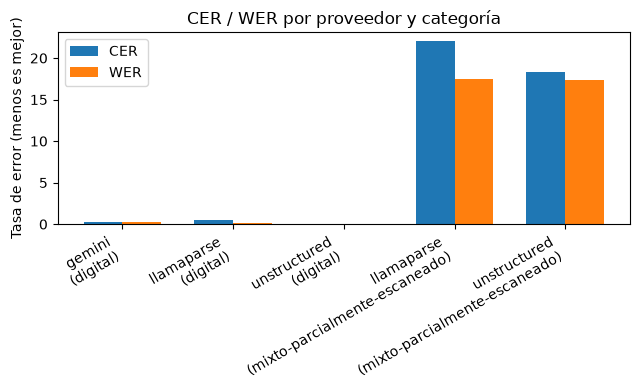

In [9]:
import matplotlib.pyplot as plt

con_referencia = [a for a in agregados if a.cer is not None]

if not con_referencia:
    print("Ningún agregado tiene CER/WER — revisar que RUTA_RESULTADOS apunte a la corrida correcta.")
else:
    etiquetas = [f"{a.extractor}\n({a.categoria})" for a in con_referencia]
    cer = [a.cer for a in con_referencia]
    wer = [a.wer for a in con_referencia]

    x = range(len(etiquetas))
    ancho = 0.35

    fig, ax = plt.subplots(figsize=(max(6, len(etiquetas) * 1.3), 4))
    ax.bar([i - ancho / 2 for i in x], cer, ancho, label="CER")
    ax.bar([i + ancho / 2 for i in x], wer, ancho, label="WER")
    ax.set_xticks(list(x))
    ax.set_xticklabels(etiquetas, rotation=30, ha="right")
    ax.set_ylabel("Tasa de error (menos es mejor)")
    ax.set_title("CER / WER por proveedor y categoría")
    ax.legend()
    fig.tight_layout()
    plt.show()

## Detalle por documento

Una fila por documento, una columna por proveedor — para ver si un número
agregado esconde un documento puntual que salió mal. `—` significa que ese
documento no tiene `.gt.txt` (no se puede calcular CER ahí).

In [10]:
from IPython.display import HTML

extractores_probados = sorted({f.extractor for f in filas})
por_documento: dict[str, dict[str, Fila]] = {}
for f in filas:
    por_documento.setdefault(f.documento, {})[f.extractor] = f

encabezado = "<th style='text-align:left'>Documento</th>" + "".join(
    f"<th>{e}</th>" for e in extractores_probados
)
cuerpo = ""
for nombre, por_extractor in por_documento.items():
    celdas = []
    for extractor in extractores_probados:
        fila = por_extractor.get(extractor)
        if fila is None:
            celdas.append("<td>—</td>")
        elif fila.error:
            celdas.append(f"<td style='color:#b00'>error: {fila.error}</td>")
        elif fila.texto is not None:
            celdas.append(f"<td>CER {fila.texto['cer']:.3f}</td>")
        else:
            celdas.append(f"<td>{fila.caracteres} caract. (sin gt)</td>")
    cuerpo += f"<tr><td style='vertical-align:top'>{nombre}</td>{''.join(celdas)}</tr>"

HTML(f"<table><tr>{encabezado}</tr>{cuerpo}</table>")

Documento,gemini,llamaparse,unstructured
Anexo Especificaciones Técnicas Accesorios Ergonómicos.pdf,CER 0.115,CER 0.771,CER 0.065
CDP_02_311_30072026_LICITACIÓN_MÓVILES__SALUD.pdf,CER 0.285,CER 0.302,CER 0.185
Especificaciones Técnicas DEA LIFEPAK 1000.pdf,CER 0.239,CER 1.019,CER 0.000
RES._2016.pdf,error: HTTPError: HTTP Error 429: Too Many Requests,CER 0.067,CER 0.008
TDR_Curso_PAC_SERVIU_2026.pdf,error: HTTPError: HTTP Error 429: Too Many Requests,CER 0.160,CER 0.029
ANEXO A BASES TÉCNICAS CURSO EXTRAINSTITUCIONAL.pdf,9760 caract. (sin gt),16187 caract. (sin gt),9492 caract. (sin gt)
BASES_DE_LICITACION_2585-79-LE26.pdf,error: HTTPError: HTTP Error 429: Too Many Requests,117200 caract. (sin gt),102939 caract. (sin gt)
D.A._N°_9253_QUE_APRUEBA_BASES_DE_LICITACION_2585-79-LE26.pdf,error: HTTPError: HTTP Error 429: Too Many Requests,122510 caract. (sin gt),111095 caract. (sin gt)
RES.703-26_-_APRUEBA_BASES.pdf,error: HTTPError: HTTP Error 429: Too Many Requests,256876 caract. (sin gt),182745 caract. (sin gt)
BASES_PP-86-2026_ok.pdf,error: HTTPError: HTTP Error 429: Too Many Requests,CER 21.999,CER 18.315


## Revisión manual de un documento puntual (opcional, hace una llamada real)

El benchmark no guarda el texto extraído completo, solo las métricas — así
que para revisar a ojo un `escaneado-limpio` (sin `.gt.txt`) hay que volver a
extraerlo. Esta celda **sí llama a la API** del proveedor elegido, una vez,
para un solo documento. No la corras salvo que quieras gastar esa llamada a
propósito — por eso está comentada.

In [11]:
# from dotenv import load_dotenv
# load_dotenv(Path.cwd() / ".env")
# from ocr_bench.extractors import REGISTRO
#
# EXTRACTOR = "gemini"  # o "document-ai", "unstructured", "llamaparse"
# DOCUMENTO = CORPUS_RAIZ / "escaneado-limpio" / "BASES_DE_LICITACION_2585-79-LE26.pdf"
#
# extraccion = REGISTRO[EXTRACTOR].extraer(DOCUMENTO)
# print(extraccion.texto[:3000])